# Linear Regression

A linear model creates a linear function based on the input features to make predictions.  
In linear regression, the regression coefficients are calculated using the method of least squares.

**Least Squares Method**: This method finds the regression coefficients that minimize the mean squared error between the predicted values and the actual target values (Y) in the training set.


In [532]:
# Import the relevant libraries
# For these lessons we will need NumPy, pandas, matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [533]:
# import warnings
# warnings.filterwarnings("ignore")

![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)

# 1. Single Linear Regression (SAT & GPA data)

## 1. load data -> plot scatter

In [534]:
# We start by loading the data
df = pd.read_csv("./data/1.01. Simple linear regression.csv")
df

,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54
3,1685,2.74
4,1693,2.83
...,...,...
79,1936,3.71
80,1810,3.71
81,1987,3.73
82,1962,3.76


<Axes: xlabel='SAT', ylabel='GPA'>

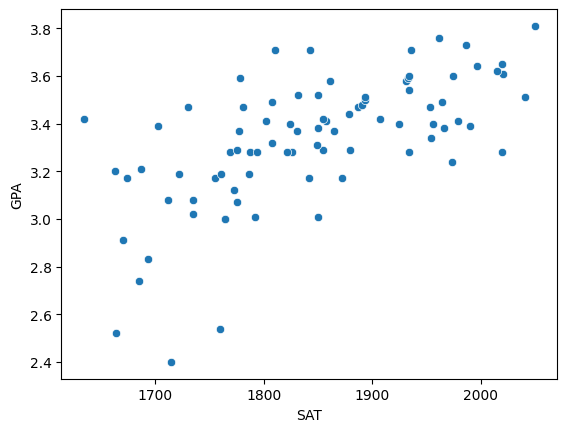

In [535]:
# Plot scatter (either using seaborn or matplotlib)
sns.scatterplot(x="SAT", y="GPA", data=df)

Text(0, 0.5, 'GPA')

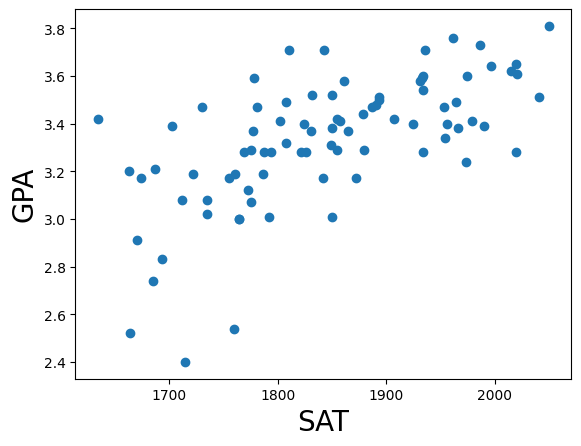

In [536]:
plt.plot(df["SAT"], df["GPA"], "o")
plt.xlabel("SAT", fontsize=20)
plt.ylabel("GPA", fontsize=20)

## 2. Declare the dependent and independent variables
- There is a single independent variable: 'SAT'
- and a single depended variable: 'GPA'

In [537]:
x = df["SAT"]
y = df["GPA"]

We are doing linear regression, so input X must be 2D. We need to reshape X to be (N, 1) form if it is 1D.

In [538]:
x_matrix = x.values.reshape(-1, 1)
print("Before reshape:", x.shape)  # (84,1)
print("After reshape:", x_matrix.shape)
x_matrix

Before reshape: (84,)
After reshape: (84, 1)


array([[1714],
       [1664],
       [1760],
       [1685],
       [1693],
       [1670],
       [1764],
       [1764],
       [1792],
       [1850],
       [1735],
       [1775],
       [1735],
       [1712],
       [1773],
       [1872],
       [1755],
       [1674],
       [1842],
       [1786],
       [1761],
       [1722],
       [1663],
       [1687],
       [1974],
       [1826],
       [1787],
       [1821],
       [2020],
       [1794],
       [1769],
       [1934],
       [1775],
       [1855],
       [1880],
       [1849],
       [1808],
       [1954],
       [1777],
       [1831],
       [1865],
       [1850],
       [1966],
       [1702],
       [1990],
       [1925],
       [1824],
       [1956],
       [1857],
       [1979],
       [1802],
       [1855],
       [1907],
       [1634],
       [1879],
       [1887],
       [1730],
       [1953],
       [1781],
       [1891],
       [1964],
       [1808],
       [1893],
       [2041],
       [1893],
       [1832],
       [18

## 3. Creating a Regression Model

To create a simple linear regression model, you can use the `LinearRegression` class from `sklearn.linear_model`.

Reference: [LinearRegression documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

In this example, we use the `LinearRegression` module from `sklearn.linear_model` to create a regression model and fit it to the data using the method of least squares aka `mse`. And we are going to skip `scaling` and `train-test-split` here because these topics are out of scope


In [539]:
from sklearn.linear_model import LinearRegression  # load module

In [540]:
# We start by creating a linear regression object
reg1 = LinearRegression()
reg1.fit(x_matrix, y)  # first arg: independent var, seoncd arg dependent var

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 4. Checking Result

### Interpretation of Coefficients

Regression coefficients represent the change in the dependent variable `y` for a one-unit change in the independent variable `x`, holding all other variables constant.
- The regression coefficient ($\beta_i$) indicates how much $y$ changes when $x_i$ increases by 1 unit.  
- For example, if the regression coefficient for **SAT** is $0.00167769$, it means that when **SAT** increases by 1 unit, **GPA** increases by approximately $0.00167769$.


In [541]:
# Getting the coefficients of the regression
# Note that the output is an array, as we usually expect several coefficients
print("Coefficients:", reg1.coef_)

Coefficients: [0.00165569]



### Interpretation of the Intercept

The **intercept** (also called the constant term, $\beta_0$) represents the predicted value of $y$ when all the independent variables ($x_i$) are equal to 0.  

In this context, it means the expected **GPA** when **SAT = 0**.  

However, if a value like **SAT = 0** is not realistic or outside the data range, the intercept has limited practical interpretation. It is mostly used to anchor the regression line in the model.

In [542]:
# Getting the intercept of the regression
# Note that the result is a float as we usually expect a single value
print("Intercept:", reg1.intercept_)

Intercept: 0.27504029966028076


### R-squared

The explanatory power of a model can be evaluated using the **R-squared (coefficient of determination)**.  
- `R-squared`**` measures how well the model explains the variance in the dependent variable.
- An `R-squared` value close to 1 indicates a model with good **explanatory power**

In [543]:
r_squared = reg1.score(x_matrix, y)
print("R-squared:", r_squared)

R-squared: 0.40600391479679754


## 5. Making predictions

There is a dedicated method should we want to predict values. Note that the result is an array, as we can predict more than one value at a time

In [544]:
reg1.predict([[2000]])  # 2D array with one value

array([3.5864164])

In [545]:
reg1.predict(
    [[2005], [2100], [1950]]
)  # 2D array. Because we can predict one or more numbers

array([3.59469484, 3.7519852 , 3.503632  ])

In [546]:
# We can also predict the whole dataframe in bulk
gpa_df = pd.DataFrame(data=[1605, 1760, 2399], columns=["SAT"])
result = reg1.predict(gpa_df)
result

/Users/I751244/Desktop/soop/datascience/ds101/.dsenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


array([2.93241962, 3.18905127, 4.24703593])

In [547]:
# Finally, we can directly store the predictions in a new series of the same dataframe
gpa_df["Predicted_GPA"] = result
gpa_df

,SAT,Predicted_GPA
0,1605,2.932420
1,1760,3.189051
2,2399,4.247036


### Plotting the Regression Line on a Scatter Plot

To visualize the regression model, we can plot the regression line along with the scatter plot of the data points.

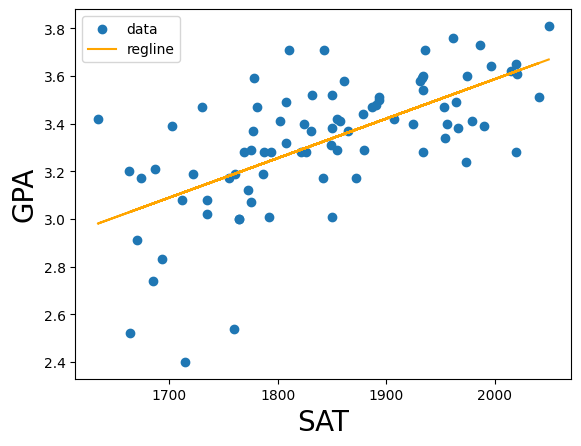

In [548]:
# There are different ways to plot the data - here's the matplotlib code
plt.scatter(x, y)

# Parametrized version of the regression line
yhat = reg1.coef_ * x_matrix + reg1.intercept_  # y = a*x + b

# Plotting the regression line
plt.plot(x, yhat, c="orange")

# Labelling our axes
plt.legend(["data", "regline"])
plt.xlabel("SAT", fontsize=20)
plt.ylabel("GPA", fontsize=20)
plt.show()

![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)

# 2. Multi Linear Regression (SAT & With Random Data & GPA data)

When there are two or more independent variables, the regression is called Multiple Linear Regression.

$$y = ax + b$$
$$GPA = a * SAT + b$$
$$GPA = a1 * SAT + a2 * RandNumb + b$$

In [549]:
# For these lessons we will need NumPy, pandas, matplotlib and seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# and of course the actual regression (machine learning) module
from sklearn.linear_model import LinearRegression

## (1) Load Data And Build Regression Model

In [550]:
# Load the data from a .csv in the same folder
df = pd.read_csv("./data/1.02. Multiple linear regression.csv")
df

,SAT,"Rand 1,2,3",GPA
0,1714,1,2.40
1,1664,3,2.52
2,1760,3,2.54
3,1685,3,2.74
4,1693,2,2.83
...,...,...,...
79,1936,3,3.71
80,1810,1,3.71
81,1987,3,3.73
82,1962,1,3.76


In [551]:
# There are two independent variables: 'SAT' and 'Rand 1,2,3'
x = df[["SAT", "Rand 1,2,3"]]
# and a single depended variable: 'GPA'
y = df["GPA"]

In [552]:
# We start by creating a linear regression object
reg2 = LinearRegression()
# The whole learning process boils down to fitting the regression
reg2.fit(x, y)
# note that we do not need to reshape x here.

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## (2) Checking the result

### coefficient and intercept
🤔 you will see absolute value of the coefficient of Random123 is greater than SAT score. Does that mean Random123 is more important feature?

In [553]:
# Getting the intercept of the regression
# Note that the result is a float as we usually expect a single value
reg2.intercept_

np.float64(0.2960326126490975)

In [554]:
# Getting the coefficients of the regression
# Note that the output is an array
reg2.coef_

array([ 0.00165354, -0.00826982])

### 🔍 Interpreting Coefficients in Multiple Linear Regression

In multiple linear regression, the size of the regression coefficient ($\beta_i$) tells us how much the dependent variable $y$ changes when the feature $x_i$ increases by 1 unit, **keeping all other variables constant**.



#### Can We Compare Coefficient Sizes?

By default, **you should NOT compare coefficient magnitudes directly**, because features may have different units or scales (e.g., SAT scores vs. GPA vs. hours studied).



#### When Can We Compare Coefficient Magnitudes?

You **can** compare the absolute values of the coefficients **only if all features are on the same scale**.

Common ways to ensure same scale:
- Standardization (mean = 0, std = 1)
- Normalization (min = 0, max = 1)



#### Example: Standardized Coefficients

Suppose you've standardized your features, and you get:

$$
\text{GPA} = 0.8 \cdot \text{SAT (std)} - 1.2 \cdot \text{HS GPA (std)}
$$

Then:
- SAT: 1 std ↑ → GPA increases by 0.8
- HS GPA: 1 std ↑ → GPA decreases by 1.2

Since $|-1.2| > |0.8|$, **HS GPA is the more influential predictor** (in terms of effect size on GPA).



#### 🧠 Summary

| Condition                          |  coefficients comparable? |
|-----------------------------------|-------------------------------|
| Raw features with different scales | ❌ No !!!!!                        |
| Features with the same scale      | ✅ Yes Larger coefficient → greater impact|


**Tip:** To make coefficients comparable, use `StandardScaler` or `MinMaxScaler` from `sklearn.preprocessing` before fitting the model.


## (3) Remodel using standardized data

In [555]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# recall
x = df[["SAT", "Rand 1,2,3"]]
y = df["GPA"]

x_scaled = scaler.fit_transform(x)

reg2.fit(x_scaled, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### coefficient and intercept

In [556]:
# now we can see SAT score is much more powerful compared to random number
print(reg2.coef_)
print(reg2.intercept_)

[ 0.17181389 -0.00703007]
3.330238095238095


### Creating a Summary Table

Let's create a new DataFrame with the names of the features.
`Weights` refers to the regression coefficients in the regression equation.In machine learning, the term `weights` is more commonly used than `regression coefficients`.


In [557]:
reg_summary_df = pd.DataFrame([["Bias"], ["SAT"], ["Rand 1,2,3"]], columns=["Features"])
reg_summary_df["Weights"] = reg2.intercept_, reg2.coef_[0], reg2.coef_[1]
reg_summary_df

,Features,Weights
0,Bias,3.330238
1,SAT,0.171814
2,"Rand 1,2,3",-0.007030


## (4) Prediction
- let's predict a student's gpa whose SAT score is 1900 and random varaible with 1

In [558]:
sample = [[1900, 1]]
reg2.predict(sample)
# You will get wrong result! How GPA could be 329?
# You need to put scaled sample well because the model was fitted with scaled values

array([329.76960424])

In [559]:
sample = [[1900, 1]]
sample_scaled = scaler.transform(sample)
reg2.predict(sample_scaled)  # Good!

/Users/I751244/Desktop/soop/datascience/ds101/.dsenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([3.42949221])

---

## (5) Model Evaluation

#### `R-squared`

The `R-squared` is used to evaluate the model's performance. It measures the proportion of variance in the dependent variable that can be explained by the independent variables. A higher `R-squared` value indicates a better model fit.

#### `Adjusted R-squared`

Adding more independent variables to a model can artificially inflate the R-squared value, even if the new variables do not meaningfully contribute to the model's predictive power. The $R^2$ addresses this issue by penalizing the addition of irrelevant variables. 


$R^2_{adj.} = 1 - (1-R^2)*\frac{n-1}{n-p-1}$

In [560]:
r2 = reg2.score(x_scaled, y)
r2

0.40668119528142843

- `n`: Number of observations is the shape along axis 0. Here, you n = 84
- `p`: Number of features (predictors, p) is the shape along axis 1. Here p = 2

In [567]:
# If we want to find the Adjusted R-squared we can do so by knowing the r2
n = x.shape[0]
p = x.shape[1]

# We find the Adjusted R-squared using the formula
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
adjusted_r2  # a bit decreased from r

0.39203134825134023

### MSE / RMSE

Mean Squared Error (MSE) & Root Mean Squared Error (RMSE)

The **Mean Squared Error (MSE)** and **Root Mean Squared Error (RMSE)** are common metrics used to evaluate regression models.  
Both measure the difference between predicted values ($\hat{y}_i$) and actual values ($y_i$), but they do so in slightly different ways.


#### ✅ Mean Squared Error (MSE)

MSE measures the **average of the squared differences** between actual and predicted values.

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

- **Penalizes larger errors more** due to squaring.
- Always non-negative; closer to 0 is better.
- **Sensitive to outliers**.
- **Not in the same unit** as the original target variable (units are squared).


#### ✅ Root Mean Squared Error (RMSE)

RMSE is simply the **square root of MSE**, bringing the error metric back to the **original unit** of the target variable.

$$
\text{RMSE} = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 }
$$

- Same interpretation as MSE, but **in the original units of $y$**, which makes it more intuitive.
- Commonly preferred for reporting model accuracy in real-world terms (e.g., "average error in GPA units").


#### Which One Is More Important?

While both are mathematically valid, **RMSE is often more interpretable in practice** because:

- It expresses the error in the **same unit as the target variable** (e.g., dollars, GPA, etc.).
- It gives a direct sense of “how far off” the model is, on average.


#### 🧠 Summary

| Metric | Formula | Units | Penalizes large errors? | Interpretability |
|--------|---------|--------|--------------------------|------------------|
| MSE    | $\frac{1}{n} \sum (y_i - \hat{y}_i)^2$ | Squared units (e.g., GPA²) | ✅ Yes (squares error) | ❌ Less interpretable |
| RMSE   | $\sqrt{\text{MSE}}$                    | Original units (e.g., GPA) | ✅ Yes (via MSE)       | ✅ Easier to interpret |


**Tip:** Use RMSE when you want to communicate model performance in a way that is meaningful to non-technical stakeholders.


In [562]:
from sklearn.metrics import root_mean_squared_error

y_true = y
y_pred = reg2.predict(x_scaled)

rmse = root_mean_squared_error(y_true, y_pred)
print("MSE = ", rmse)

MSE =  0.2079699366863159
